In [1]:
# 1. Instalación
!pip install -q segmentation-models-pytorch albumentations

You should consider upgrading via the 'c:\users\user\segmentacion-vertebras-proyecto-maia\.venv\scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
import sys
print(sys.executable)

c:\Users\USER\segmentacion-vertebras-proyecto-maia\.venv\Scripts\python.exe


In [3]:
%pip install numpy pandas opencv-python matplotlib torch torchvision albumentations segmentation-models-pytorch scikit-learn ipykernel

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\USER\segmentacion-vertebras-proyecto-maia\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [1]:
# 2. Importaciones
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

from sklearn.model_selection import train_test_split

c:\Users\USER\segmentacion-vertebras-proyecto-maia\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# 3. Configuración
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE = 512
BATCH_SIZE = 4
EPOCHS = 15
LR = 1e-4

In [2]:
from pathlib import Path
import os

DATASET_ROOT = Path(r"C:\Users\USER\Scoliosis_Dataset")
DATASET_INDEX = DATASET_ROOT / "indice_dataset.csv"
NORMAL_DIR = DATASET_ROOT / "Normal"
SCOLIOSIS_DIR = DATASET_ROOT / "Scoliosis"
MASK_DIR = DATASET_ROOT / "LabelBinaryJPG"

# Todas las imágenes
all_images = list(NORMAL_DIR.glob("*")) + list(SCOLIOSIS_DIR.glob("*"))

# Diccionario de máscaras por nombre
mask_dict = {p.name: p for p in MASK_DIR.glob("*")}

image_paths = sorted([str(p) for p in all_images])
mask_paths = sorted([str(p) for p in MASK_DIR.glob("*")])

print(len(image_paths), len(mask_paths))

for img_path in all_images:
    if img_path.name in mask_dict:
        image_paths.append(str(img_path))
        mask_paths.append(str(mask_dict[img_path.name]))

print(f"Imágenes emparejadas: {len(image_paths)}")
print(f"Máscaras emparejadas: {len(mask_paths)}")
print("Ejemplo:")
print(image_paths[0])
print(mask_paths[0])

249 249
Imágenes emparejadas: 249
Máscaras emparejadas: 249
Ejemplo:
C:\Users\USER\Scoliosis_Dataset\Normal\N_1.jpg
C:\Users\USER\Scoliosis_Dataset\LabelBinaryJPG\Label_N_1.jpg


In [6]:
print(os.listdir(DATASET_ROOT))

['diccionario_etiquetas_T1_T12_L1_L5.json', 'indice_dataset.csv', 'LabelBinaryJPG', 'LabelMultiClass_Color_JPG', 'LabelMultiClass_Gray_JPG', 'LabelMultiClass_ID_PNG', 'Normal', 'RadiographMetrics', 'README.md', 'reporte_por_mascara_version_final.csv', 'resumen_diccionario_original_35_entidades.csv', 'resumen_version_final_T1_T12_L1_L5.csv', 'Scoliosis']


In [7]:
for i in range(5):
    print(os.path.basename(image_paths[i]), " <-> ", os.path.basename(mask_paths[i]))

N_1.jpg  <->  Label_N_1.jpg
N_10.jpg  <->  Label_N_10.jpg
N_11.jpg  <->  Label_N_11.jpg
N_12.jpg  <->  Label_N_12.jpg
N_13.jpg  <->  Label_N_13.jpg


In [8]:
class VertebrasDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = cv2.imread(self.images[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.masks[idx])
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

        mask = self.rgb_to_binary(mask)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image.float(), mask.unsqueeze(0).float()

    def rgb_to_binary(self, mask):
        return (np.sum(mask, axis=2) > 10).astype(np.float32)

In [9]:
# 5. Dataset
class VertebrasDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = cv2.imread(self.images[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.masks[idx])
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

        mask = self.rgb_to_binary(mask)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        image = image.float()
        mask = mask.float()

        return image.float(), mask.unsqueeze(0).float()

    def rgb_to_binary(self, mask):
        # cualquier pixel con intensidad > 10 = vertebra
        return (np.sum(mask, axis=2) > 10).astype(np.float32)



In [10]:
# 6. Transformaciones

# Añade el paso de Normalize
transform_comun = [
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
]

train_transform = A.Compose([A.HorizontalFlip(p=0.5)] + transform_comun)
val_transform = A.Compose(transform_comun)

In [11]:
# 7. Split
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)

train_dataset = VertebrasDataset(train_imgs, train_masks, train_transform)
val_dataset = VertebrasDataset(val_imgs, val_masks, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [12]:
# 8. Modelo U-Net
model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1
).to(DEVICE)

In [13]:
# 9. Loss y optimizador
loss_fn = smp.losses.DiceLoss(mode='binary', from_logits=True)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [14]:
# 10. Métrica Dice
def dice_score(preds, targets, smooth=1e-6):
    preds = (preds > 0.5).float()
    intersection = (preds * targets).sum()
    return (2 * intersection + smooth) / (preds.sum() + targets.sum() + smooth)


N_1.jpg <-> Label_N_1.jpg


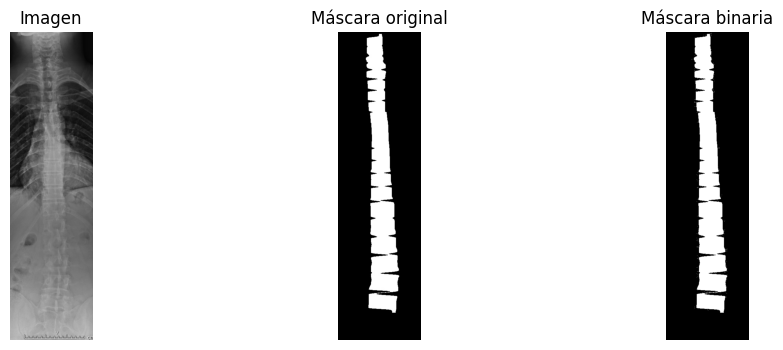

N_10.jpg <-> Label_N_10.jpg


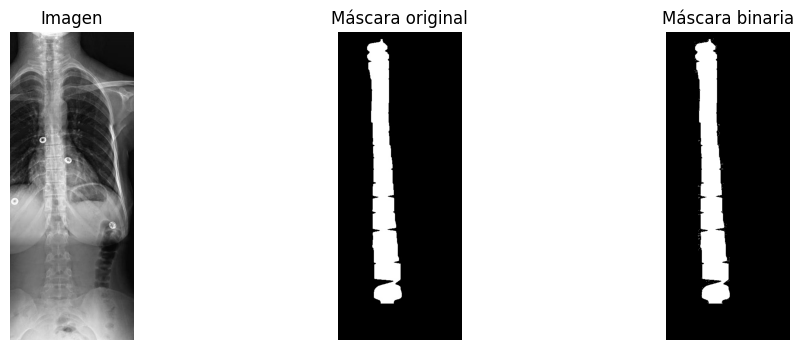

N_11.jpg <-> Label_N_11.jpg


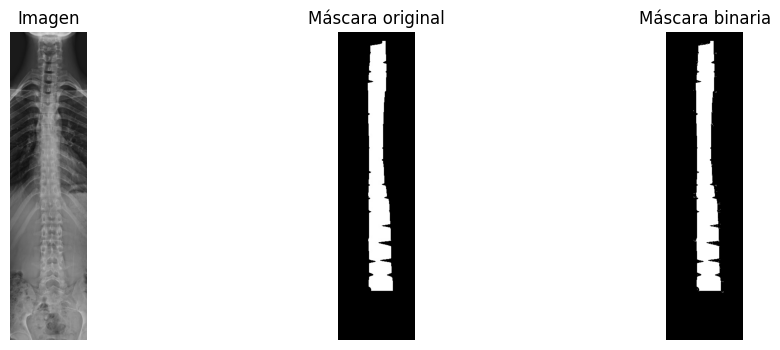

N_12.jpg <-> Label_N_12.jpg


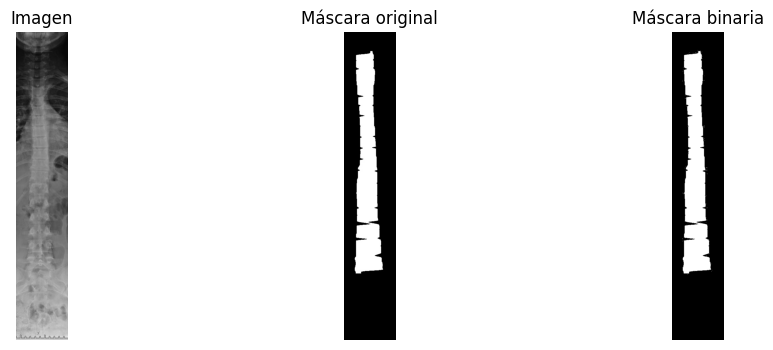

N_13.jpg <-> Label_N_13.jpg


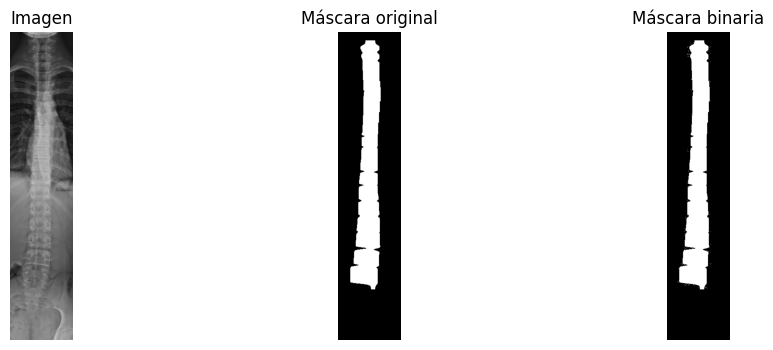

In [ ]:
#Comparacion aleatoria de coincidencia entre imagenes y mascaras:

import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

def show_pair(img_path, mask_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
    mask_bin = (np.sum(mask, axis=2) > 10).astype(np.uint8)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Imagen")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask)
    plt.title("Máscara original")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(mask_bin, cmap="gray")
    plt.title("Máscara binaria")
    plt.axis("off")

    plt.show()

for i in range(5):
    print(os.path.basename(image_paths[i]), "<->", os.path.basename(mask_paths[i]))
    show_pair(image_paths[i], mask_paths[i])

In [16]:
mask_ratios = []

for m in mask_paths[:100]:
    mask = cv2.imread(m)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
    mask_bin = (np.sum(mask, axis=2) > 10).astype(np.float32)
    mask_ratios.append(mask_bin.mean())

print("Promedio de píxeles positivos:", np.mean(mask_ratios))
print("Mínimo:", np.min(mask_ratios))
print("Máximo:", np.max(mask_ratios))

Promedio de píxeles positivos: 0.17958763
Mínimo: 0.073575325
Máximo: 0.32329884


In [17]:
# 2. Importaciones
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

from sklearn.model_selection import train_test_split

In [18]:
# 11. Entrenamiento
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        preds = model(images)
        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_dice = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            preds = torch.sigmoid(model(images))
            val_dice += dice_score(preds, masks)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"Val Dice: {val_dice/len(val_loader):.4f}")


Epoch 1
Train Loss: 0.5611
Val Dice: 0.7858
Epoch 2
Train Loss: 0.3884
Val Dice: 0.8662
Epoch 3
Train Loss: 0.3008
Val Dice: 0.8736
Epoch 4
Train Loss: 0.2451
Val Dice: 0.8977
Epoch 5
Train Loss: 0.2017
Val Dice: 0.8983
Epoch 6
Train Loss: 0.1721
Val Dice: 0.8958
Epoch 7
Train Loss: 0.1490
Val Dice: 0.8997
Epoch 8
Train Loss: 0.1341
Val Dice: 0.8979
Epoch 9
Train Loss: 0.1186
Val Dice: 0.9004
Epoch 10
Train Loss: 0.1061
Val Dice: 0.9122
Epoch 11
Train Loss: 0.1000
Val Dice: 0.9172
Epoch 12
Train Loss: 0.0929
Val Dice: 0.9092
Epoch 13
Train Loss: 0.0870
Val Dice: 0.9014
Epoch 14
Train Loss: 0.0815
Val Dice: 0.9159
Epoch 15
Train Loss: 0.0779
Val Dice: 0.9126


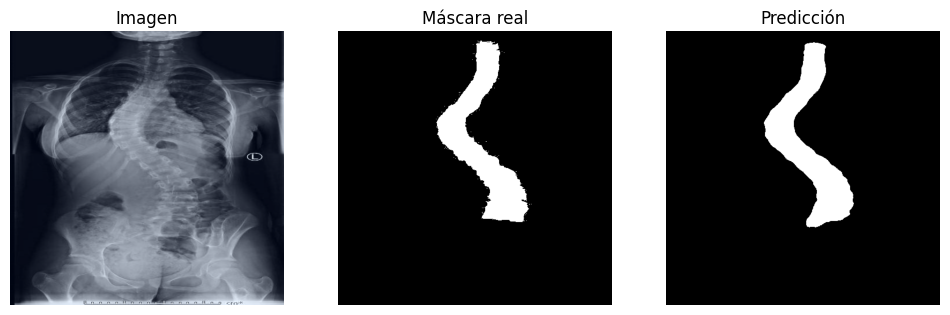

In [19]:
model.eval()

images, masks = next(iter(val_loader))
images = images.to(DEVICE)

with torch.no_grad():
    probs = torch.sigmoid(model(images))

preds = (probs > 0.5).float().cpu().numpy()
imgs = images.cpu().permute(0, 2, 3, 1).numpy()
true_masks = masks.numpy()

idx = 0
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow((imgs[idx] * 0.229 + 0.485).clip(0,1))  # aproximación si normalizaste con ImageNet
plt.title("Imagen")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(true_masks[idx,0], cmap="gray")
plt.title("Máscara real")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(preds[idx,0], cmap="gray")
plt.title("Predicción")
plt.axis("off")

plt.show()

In [20]:
# 12. Predicción
def predict_image(model, image_path, transform):
    model.eval()
    
    # Leer imagen original
    image_cv = cv2.imread(image_path)
    image_cv = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = image_cv.shape[:2] # Guardamos alto y ancho originales

    # Aplicar EXACTAMENTE la misma transformación de validación
    # Esto maneja el Resize y el ToTensorV2 correctamente
    augmented = transform(image=image_cv)
    image_tensor = augmented['image'].unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        output = model(image_tensor)
        # Aplicamos sigmoid para obtener probabilidades entre 0 y 1
        probs = torch.sigmoid(output)[0][0].cpu().numpy()

    # Escalar la predicción (mapa de probabilidades) al tamaño original
    # Usamos INTER_LINEAR para suavizar las probabilidades
    probs_orig_size = cv2.resize(probs, (w_orig, h_orig), interpolation=cv2.INTER_LINEAR)

    # Umbral (Threshold) estándar para segmentación binaria
    mask_binary = (probs_orig_size > 0.5).astype(np.uint8)

    return image_cv, mask_binary

In [21]:
# 13. Visualización
def plot_prediction(original, pred): 
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.title("Imagen original")
    plt.imshow(original)
    plt.axis('off')
    
    plt.subplot(1,3,2)
    plt.title("Predicción (máscara)")
    plt.imshow(pred, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(original)
    plt.imshow(pred, alpha=0.5, cmap='jet')
    plt.axis('off')
    
    plt.show()

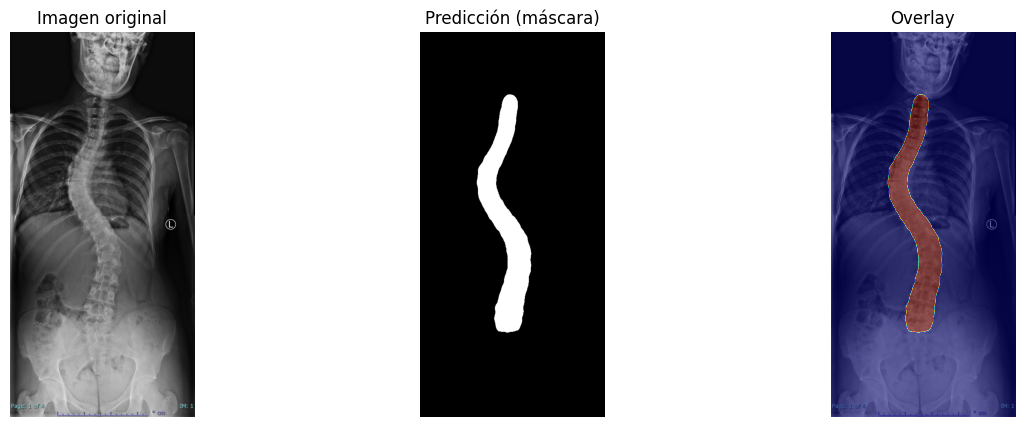

In [22]:
image_path = val_imgs[5]  # o cualquier imagen

original, pred = predict_image(model, image_path, val_transform)
plot_prediction(original, pred)

In [23]:
# Definir la ruta y nombre del archivo
MODEL_SAVE_PATH = "unet_resnet34_columna.pth"

# Guardar solo los pesos (es lo más eficiente y seguro)
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Modelo guardado exitosamente en: {MODEL_SAVE_PATH}")

Modelo guardado exitosamente en: unet_resnet34_columna.pth
